In [2]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *
# color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
#               '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

In [2]:
def powercutoff_fit(x, a, b, c, d):
    return a * x **(-b) * np.exp(-(x / c) ** d)

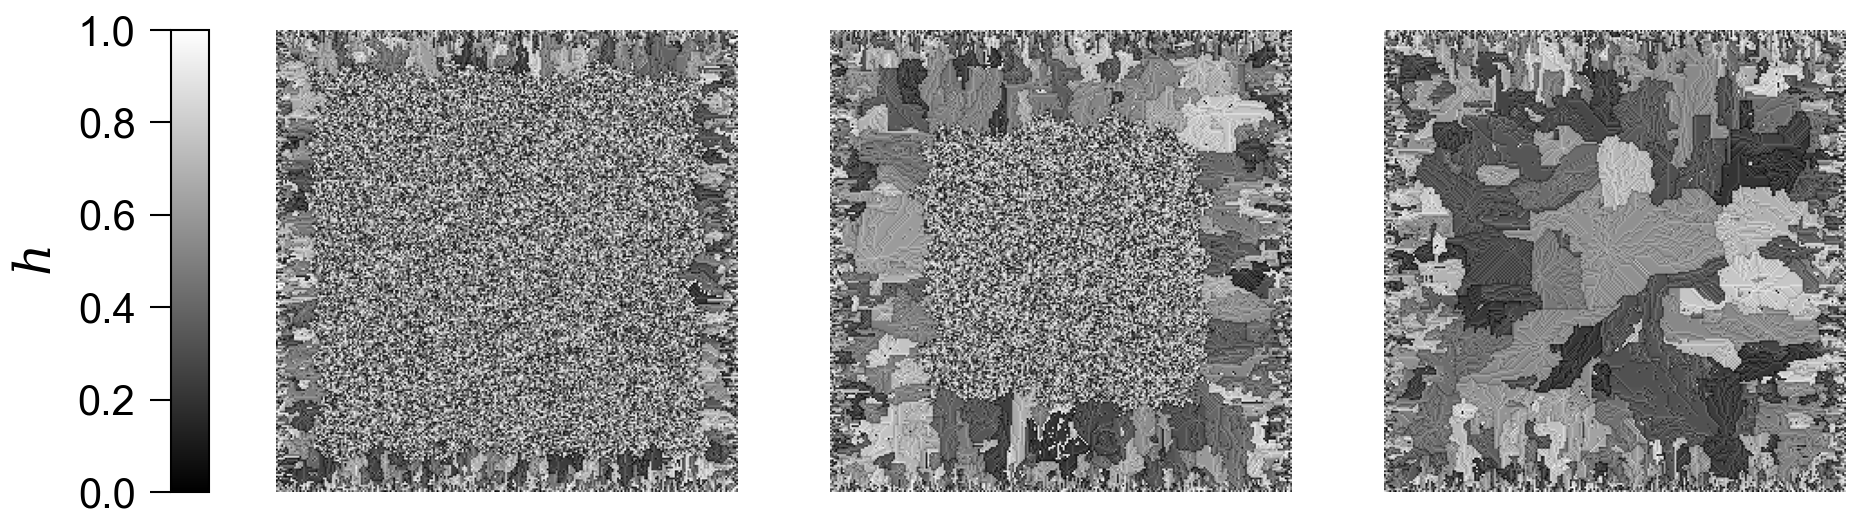

In [10]:
system1 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n14/Snapshots/nav100000000_outputB.txt").reshape(256, 256)
system2 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n14/Snapshots/nav1000000000_outputB.txt").reshape(256, 256)
system3 = np.loadtxt("/data1/DATA_Duplat/Brut/PDF/PD5n14/Snapshots/nav100000000000_outputB.txt").reshape(256, 256)

with plt.style.context(spstyle.get_style('thesis')):
    fig, axis = plt.subplots(1,3, figsize= (7.2,2.8))
    pos = axis[0].imshow(1-system1, cmap = "gray", vmin = 0, vmax = 1)
    axis[1].imshow(1-system2, cmap = "gray", vmin = 0, vmax = 1)
    axis[2].imshow(1-system3, cmap = "gray", vmin = 0, vmax = 1)
    cbar = fig.colorbar(pos, ax=axis, location = 'left', fraction=0.023, aspect = 12, pad = 0.04)
    cbar.set_label(r'$h$')
    
    axis[0].set_axis_off()
    axis[1].set_axis_off()
    axis[2].set_axis_off()
    plt.savefig("snapshots.pdf", dpi = 600)
    plt.show()

#   Litterature

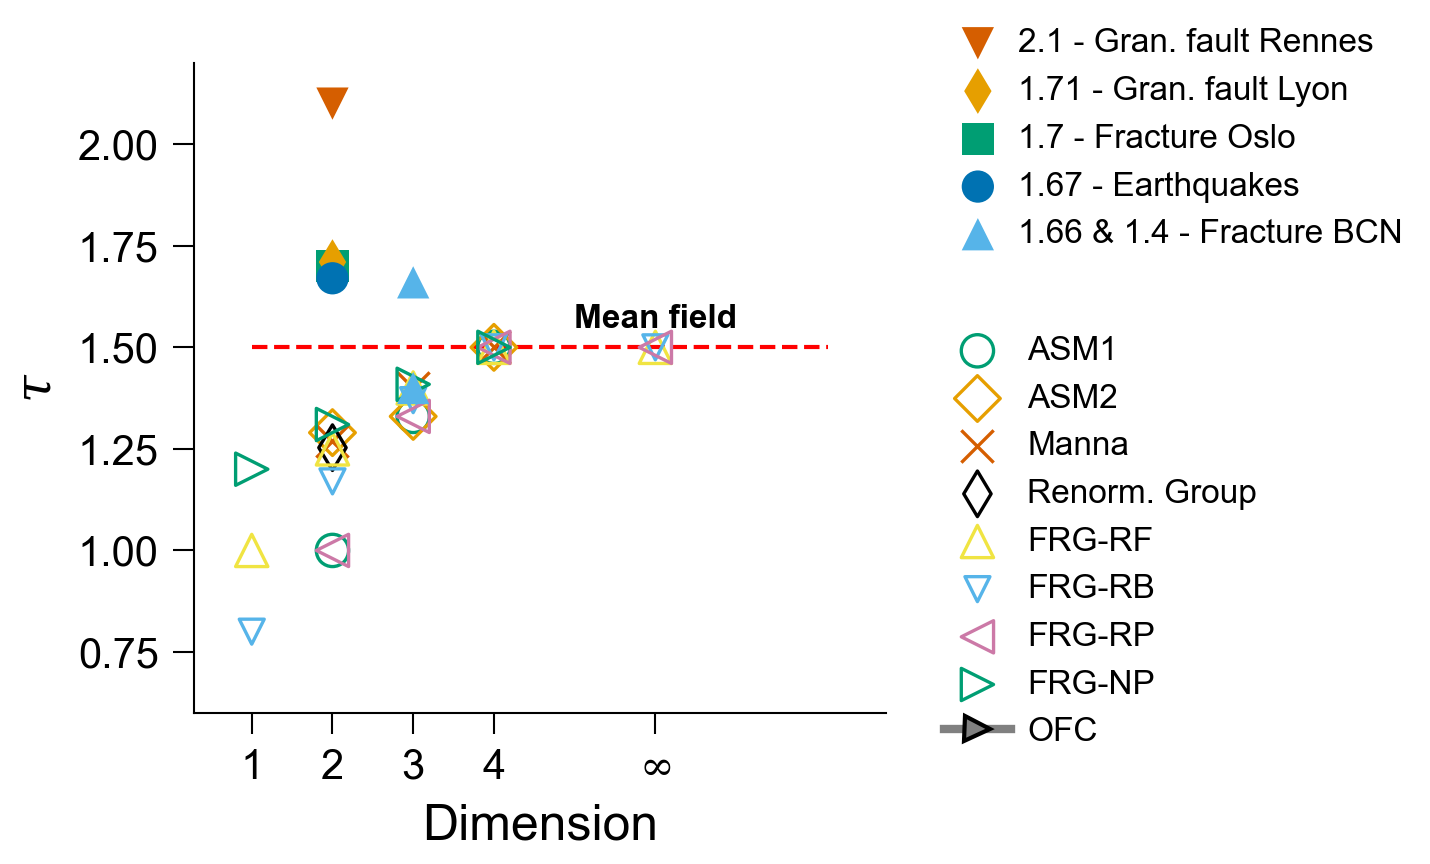

In [36]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import numpy as np
from scipy.interpolate import splprep, splev
from matplotlib.lines import Line2D

def transfo_x(x):
    return 1 + 0.7 * (np.array(x) - 1)



with plt.style.context(spstyle.get_style('thesis')):
    fig, ax1 = plt.subplots(figsize=(5.5, 2.8))
    ################## Figure 1 ##################
    Zhang_tau = [1,1.33,3/2]
    Zhang_dim = [2,3,4]
    Vespigani_tau = [1.253]
    Vespigani_dim = [2]
    Chessa_tau = [1.27]
    Chessa_dim = [2]
    Lubeck_tau = [1.29, 1.33, 3/2]
    Lubeck2_tau = [1.27, 1.4, 3/2]
    Lubeck_dim = [2,3,4]
    DW_RF_tau = [1, 1.25, 1.4, 3/2, 3/2]
    DW_RB_tau = [0.8, 1.17, 1.37, 3/2, 3/2]
    DW_RP_tau = [0, 1, 1.33, 3/2, 3/2]
    DW_Dep_tau = [1.2, 1.31, 1.409, 3/2]
    DW_dim = [1,2,3,4,6]

    EQ_tau = [1.67]
    EQ_dim = [2]
    Rennes_tau = [2.1]
    Rennes_dim = [2]
    Lyon_tau = [1.71]
    Lyon_dim = [2]
    Oslo_tau = [1.7]
    Oslo_dim = [2]
    Barcelone_tau = [1.4, 1.66]
    Barcelone_dim = [3,3]

    positions_ticks = [1, 2, 3, 4, 6]
    labels_ticks = [1, 2, 3, 4, r'$\infty$']


    ms = 60
    ms2 = ms - 100
    lw = 0.8
    ts = 6

    color_list = ['#000000', '#e69f00', '#56b4e9', '#009e73',
                '#f0e442', '#0072b2', '#d55e00', '#cc79a7']

    pt_eq = ax1.scatter(transfo_x(EQ_dim), EQ_tau, label = r"1.67 - Earthquakes",
                        facecolor = color_list[5], edgecolors = 'None', marker = "o", zorder = 20, s = ms)
    pt_rennes = ax1.scatter(transfo_x(Rennes_dim), Rennes_tau, label = r"2.1 - Gran. fault Rennes",
                            facecolor = color_list[6], edgecolors = 'None', marker = "v", zorder = 10, s = ms) 
    pt_lyon = ax1.scatter(transfo_x(Lyon_dim), Lyon_tau, label = r"1.71 - Gran. fault Lyon",
                            facecolor = color_list[1], edgecolors = 'None', marker = "d", zorder = 11, s = ms)
    pt_oslo = ax1.scatter(transfo_x(Oslo_dim), Oslo_tau, label = r"1.7 - Fracture Oslo",
                            facecolor = color_list[3], edgecolors = 'None', marker = "s", zorder = 10, s = ms)
    pt_barcelone = ax1.scatter(transfo_x(Barcelone_dim), Barcelone_tau, label = r"1.66 & 1.4 - Fracture BCN",
                           facecolor = color_list[2], edgecolors = 'None', marker = "^",  zorder = 10, s = ms)

    pt_zhang = ax1.scatter(transfo_x(Zhang_dim), Zhang_tau, label = "ASM1", facecolor = 'none', edgecolors=color_list[3], zorder = 5, marker = 'o', lw = lw, s = ms)
    pt_lubeck = ax1.scatter(transfo_x(Lubeck_dim), Lubeck_tau, label = "ASM2", facecolor = 'none', edgecolors= color_list[1], marker = 'D', zorder = 5, lw = lw, s = ms)
    pt_lubeck2 = ax1.scatter(transfo_x(Lubeck_dim), Lubeck2_tau, label = "Manna", facecolor = color_list[6], marker = 'x', zorder = 5, lw = lw, s = ms)
    pt_vesp = ax1.scatter(transfo_x(Vespigani_dim), Vespigani_tau, label = "Renorm. Group", facecolor = 'none', edgecolors = color_list[0],
                          marker = 'd', zorder = 5, lw = lw, s = ms)
    pt_dwrf = ax1.scatter(transfo_x(DW_dim), DW_RF_tau, label = "FRG-RF", facecolor = 'none', edgecolors = color_list[4], marker = "^", zorder = 6, lw = lw, s = ms)
    pt_dwrb = ax1.scatter(transfo_x(DW_dim), DW_RB_tau, label = "FRG-RB", facecolor = 'none', edgecolors = color_list[2], marker = "v", zorder = 6, lw = lw)
    pt_dwrp = ax1.scatter(transfo_x(DW_dim), DW_RP_tau, label = "FRG-RP", facecolor = 'none', edgecolors = color_list[7], marker = "<", zorder = 6, lw = lw, s = ms)
    pt_dwdep = ax1.scatter(transfo_x(DW_dim[:-1]), DW_Dep_tau, label = "FRG-NP", facecolor = 'none', edgecolors = color_list[3], marker = ">", zorder = 6, lw = lw, s = ms)

    #########REFERENCES###########
    # EQ: 
    # OSLO: Lherminier_PRL-2019
    # BCN: Baro_PRL-2013  
    # RENNES: Houdoux_cee-2021
    # LYON: Vehel_th-2021
    # ZHANG: Zhang_prl-1989
    # VESPIGANI: Vespignani_pre-1995
    # LUBECK: Lubeck_pre-1997
    # LUBECK2: Lubeck_pre-1997
    # CHESSA: Chessa_pre-1999
    # DW: Ledoussal_pre-2009

    ax1.annotate('Mean field', xy =(transfo_x([6]),1.57), xytext = (transfo_x([6]),1.57), ha = 'center', va = 'center',
                color = 'k', zorder = 100, fontweight = 'bold', fontsize = 8)
    ax1.hlines(1.5, 1, 6, color = 'red', linestyle = '--', zorder = 0)

    OFC = Line2D([0], [0], color='grey', lw=2, marker='>', label='OFC')

    ax1.set_xlabel('Dimension')
    ax1.set_ylabel(r"$\tau$")
    ax1.yaxis.labelpad = 4
    ax1.set_xticks(transfo_x(positions_ticks), labels_ticks)
    ax1.set_xlim(0.5,6.5)
    ax1.set_ylim(0.6, 2.2)
    legend1 = ax1.legend(handles=[pt_rennes, pt_lyon, pt_oslo, pt_eq, pt_barcelone],
                        loc='upper right', edgecolor = 'none', ncol = 1, handletextpad=0.2, bbox_to_anchor=[1.79,1.1])
    ax1.set_facecolor((0., 0., 0., 0.))
    ax1.add_artist(legend1)
    for text in legend1.get_texts():
        if text.get_text() == "Earthquakes":
            text.set_fontweight("bold")
            
    ax1.legend(handles=[pt_zhang, pt_lubeck, pt_lubeck2, pt_vesp, pt_dwrf, pt_dwrb, pt_dwrp, pt_dwdep, OFC]
               , loc='lower right', edgecolor = 'none', ncol = 1, handletextpad=0.5, bbox_to_anchor=[1.58,-0.1])         

    fig.patch.set_alpha(0.0)
    ax1.patch.set_alpha(0.0)
    plt.subplots_adjust(hspace=0) 
    plt.tight_layout()
    plt.savefig('Litterature.pdf', bbox_inches='tight', dpi = 300)

    plt.show()


## Figure OFC 

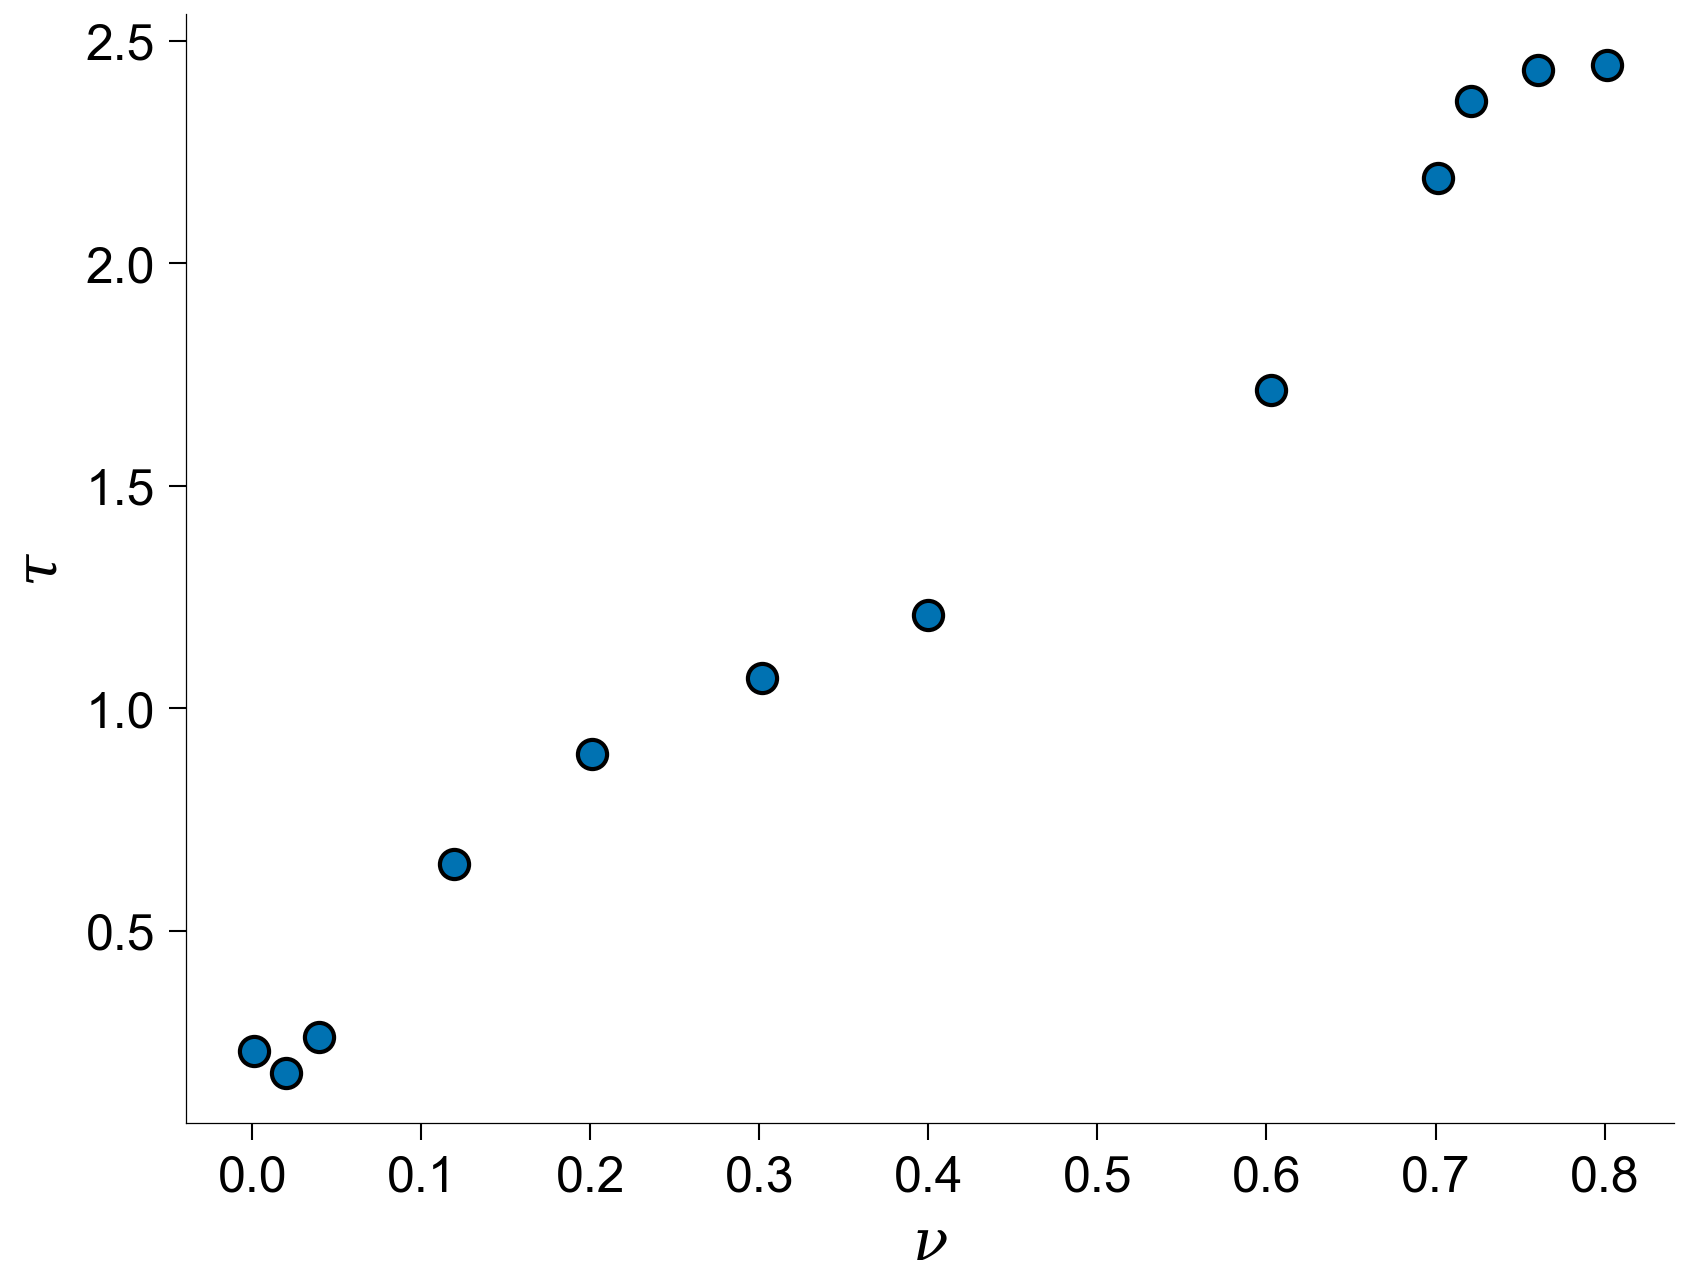

In [ ]:
coo = np.array([[0.04967069154774973, 2.4460916442048517],
[0.059824368825466524, 2.4339622641509435],
[0.06970362239297476, 2.3652291105121295],
[0.07464324917672888, 2.1913746630727764],
[0.09934138309549946, 1.7142857142857144],
[0.15010976948408344, 1.2088948787061995],
[0.17453347969264546, 1.0673854447439353],
[0.19978046103183317, 0.8975741239892184],
[0.22008781558726676, 0.6509433962264152],
[0.2401207464324918, 0.26280323450134774],
[0.24506037321624588, 0.18194070080862534],
[0.24972557628979145, 0.23045822102425878]])

x, y = coo.T
x_diss = 1-4*x

with plt.style.context(spstyle.get_style('nature-reviews')):

    plt.rcParams['font.family'] = 'Arial' 
    fig, ax = plt.subplots(figsize = (6.4,4.8))
    ax.scatter(x_diss, y, c = color_list[5])
    ax.set_xlabel(r'$\nu$')
    ax.set_ylabel(r'$\tau$')

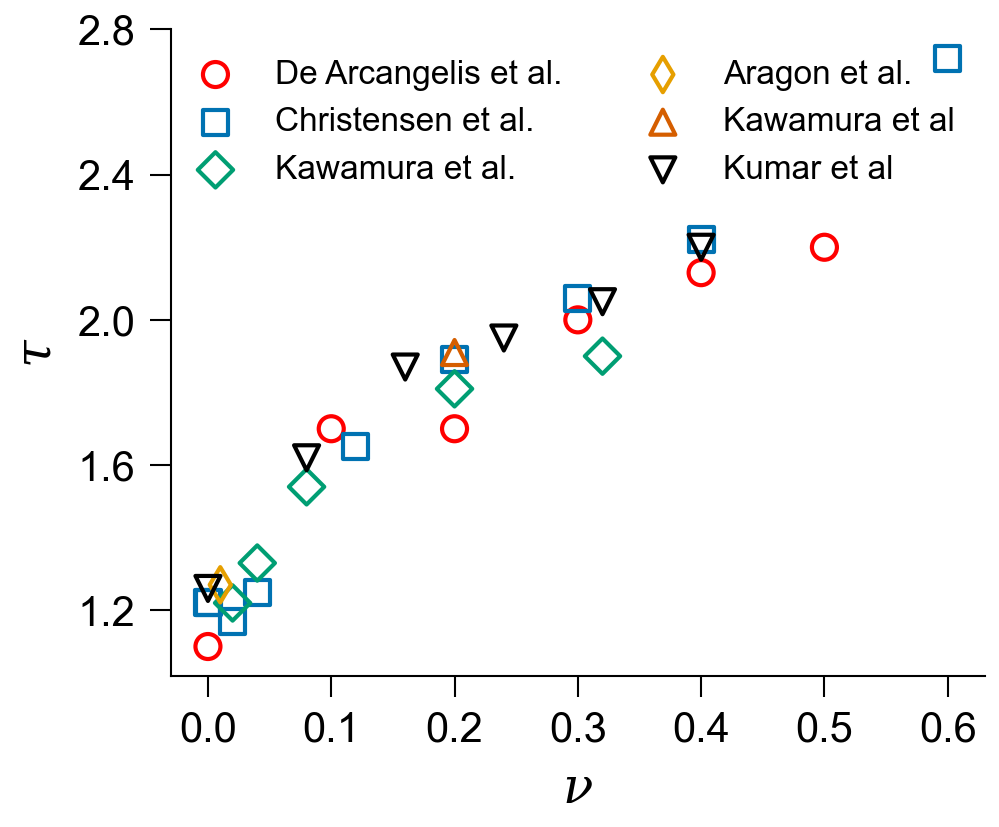

In [8]:
Arcangelis_nu = [0,0.1,  0.2, 0.3, 0.4, 0.5]
Arcangelis_slope = [1.1, 1.7 ,1.7, 2.0, 2.13, 2.20]

Chris_Olami_nu = [0, 4e-4, 0.02, 0.04, 0.12, 0.2, 0.3, 0.4, 0.6]
Chris_Olami_slope = [1.22, 1.22, 1.17, 1.25, 1.65, 1.89, 2.06, 2.22, 2.72]

Kawamura_nu = [0.02, 0.04, 0.08, 0.2, 0.32]
Kawamura_slope = [1.22,1.33,1.54,1.81,1.90]

Aragon_nu = [0.01] #OFC*, pente supposé constante
Aragon_slope = [1.27]  

Wissel_nu = [0.2]
Wissel_slope = [1.91]

Kumar_nu = [0,0.08,0.16,0.24,0.32,0.4]
Kumar_slope = [1.26,1.62,1.87,1.95,2.05,2.2]

with plt.style.context(spstyle.get_style('thesis')):
    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))
    ax1.scatter(Arcangelis_nu, Arcangelis_slope, facecolors = 'none', color = 'r', marker = 'o',label = 'De Arcangelis et al.')
    ax1.scatter(Chris_Olami_nu, Chris_Olami_slope, facecolors = 'none', color = color_list[0], marker = 's', label = 'Christensen et al.')
    ax1.scatter(Kawamura_nu, Kawamura_slope, facecolors = 'none', color = color_list[1], marker = 'D', label = 'Kawamura et al.')
    ax1.scatter(Aragon_nu, Aragon_slope, facecolors = 'none', color = color_list[2], marker = 'd', label = 'Aragon et al.')
    ax1.scatter(Wissel_nu, Wissel_slope, facecolors = 'none', color = color_list[3], marker = '^', label = 'Kawamura et al')
    ax1.scatter(Kumar_nu, Kumar_slope, facecolors = 'none', color = 'k', marker = 'v', label = 'Kumar et al')
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel(r'$\tau$')
    ax1.set_yticks([1.2, 1.6, 2.,2.4,2.8])
    ax1.set_xticks([0, 0.1, 0.2,0.3,0.4,0.5,0.6])
    
    ax1.legend(ncols = 2)
    ax1.set_alpha(0)
    fig.set_alpha(0)
    plt.savefig("Exp_litterature.pdf", dpi =600)
    plt.show()

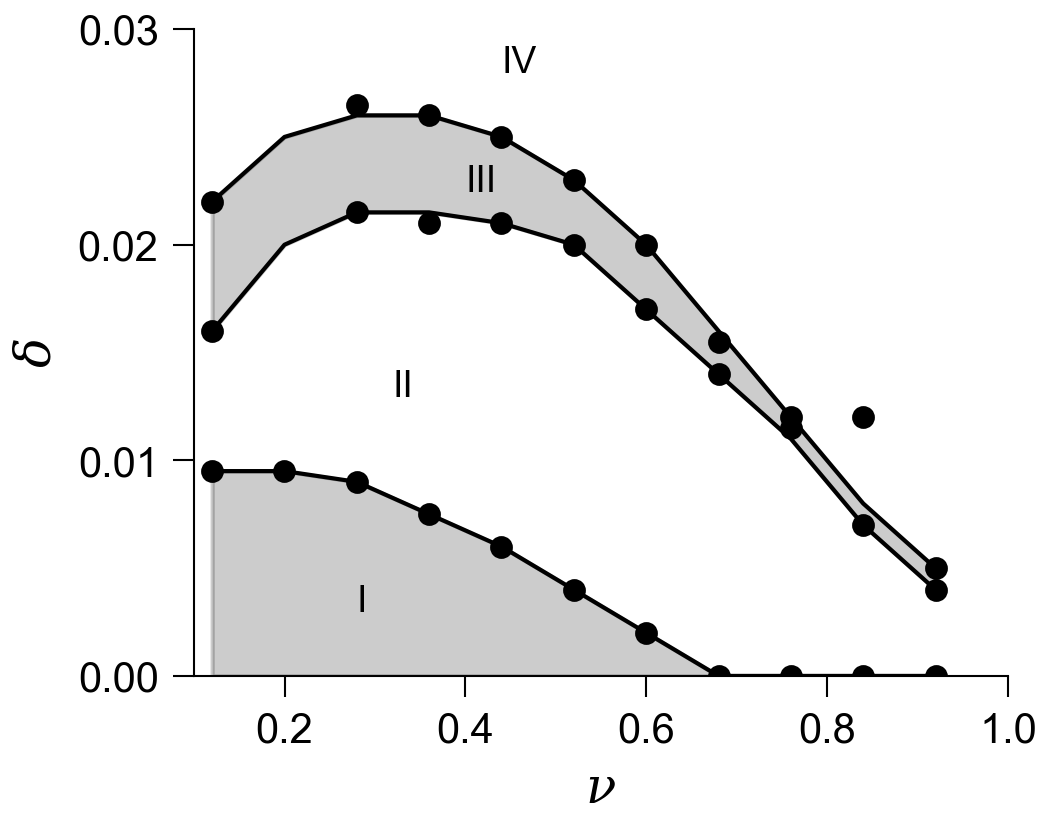

In [78]:
import matplotlib.pyplot as plt
import numpy as np

alpha = np.array([0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,0.20,0.22])
nu = 1-4*alpha
curve1 = np.array([0.0,0.0,0.0,0.0,0.002,0.004,0.006,0.0075,0.009,0.0095,0.0095])
curve2 = np.array([0.005,0.008,0.012,0.016,0.020,0.023,0.025,0.026,0.026,0.025,0.022])
curve3 = np.array([0.004,0.007,0.011,0.014,0.017,0.020,0.021,0.0215,0.0215,0.020,0.016])

alpha2 = np.array([0.02,0.04,0.06,0.08,0.10,0.12,0.14,0.16,0.18,0.22])
nu2 = 1-4*alpha2
curve4 = np.array([0.0,0.0,0.0,0.0,0.002,0.004,0.006,0.0075,0.009,0.0095,0.0095])
curve5 = np.array([0.005,0.012,0.012,0.0155,0.020,0.023,0.025,0.026,0.0265,0.022])
curve6 = np.array([0.004,0.007,0.0115,0.014,0.017,0.020,0.021,0.021,0.0215,0.016])

err = np.full_like(alpha, 0.001)

with plt.style.context(spstyle.get_style('thesis')):
    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))
    ax1.plot(nu, curve2, color='black', ms = 5)
    ax1.plot(nu, curve3, color='black', ms = 5)
    ax1.plot(nu, curve1, color='black', ms = 5)
    
    ax1.scatter(nu, curve4, marker='o', color='black', s = 20)
    ax1.scatter(nu2, curve5, marker='o', color='black', s = 20)
    ax1.scatter(nu2, curve6, marker='o', color='black', s = 20)

    ax1.fill_between(nu, curve2, curve3, where=(curve2 > curve3), color="black", alpha=0.2, label="zone")
    ax1.fill_between(nu, curve1, [0]*len(nu), where=(curve1 > -1), color="black", alpha=0.2, label="zone")
    

    # Region labels
    ax1.text(1-4*0.18, 0.003, 'I', fontsize = 9)
    ax1.text(1-4*0.17, 0.013, 'II', fontsize = 9)
    ax1.text(1-4*0.15, 0.0225, 'III', fontsize = 9)
    ax1.text(1-4*0.14, 0.028, 'IV', fontsize = 9)
    
    ax1.set_yticks([0.00,0.01,0.02,0.03])    
    ax1.set_xlabel(r'$\nu$')
    ax1.set_ylabel(r'$\delta$')
    ax1.set_xlim(0.1, 1)
    ax1.set_ylim(0, 0.03)

    plt.savefig("Mousseau_phase_transition.pdf", dpi = 600)
    plt.show()